# 05 — Tree Models (XGBoost + LightGBM)

**Goal:** Beat the linear baseline. Tune LightGBM. Compute SHAP on sample predictions. Pickle the final model.

## Results

| Model | RMSE (log) | MAE (log) | R² | RMSE (USD) |
|-------|-----------|-----------|-----|------------|
| LinearRegression baseline | see nb 04 | see nb 04 | see nb 04 | see nb 04 |
| XGBoost (default) | 0.8404 | 0.6122 | 0.6228 | $12,864 |
| LightGBM (default + early stop) | 0.8156 | 0.5967 | 0.6448 | $13,455 |
| LightGBM (tuned + early stop) | **0.8068** | **0.5908** | **0.6524** | $13,469 |

**UNCTAD feature in SHAP top-10?** YES (rank: 5 of 8)

---

## Why trees beat linear here

The linear baseline's main weakness was `route_label`: 1,800+ routes encoded as integers with a single linear slope. That's not how freight lanes work.

LightGBM solves this with **native categorical splitting**: instead of treating `route_label=42` as "42 units above route 0", it finds the optimal binary partition of route IDs that maximises information gain. This is equivalent to learning a per-route price level without one-hot explosion.

XGBoost can handle this too (with `enable_categorical` or `tree_method='hist'`) but LightGBM's implementation is faster on CPU and the sklearn interface is cleaner for our pipeline.

**Key difference from notebook 04:**  
We do NOT impute `unctad_rate_usd_kg`. LightGBM routes NaN observations to whichever child node reduces loss most — effectively learning "what mode=Other shipments look like on average" from the data rather than from our imputation choice.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap
import xgboost as xgb
import lightgbm as lgb
from pathlib import Path
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint, uniform
import sys
sys.path.insert(0, '..')

from src.features.features import feature_names, LGBM_CAT_FEATURES

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print(f"SHAP version: {shap.__version__}")
print(f"\nLGBM categorical features: {LGBM_CAT_FEATURES}")
print(f"All features: {feature_names()}")

XGBoost version: 3.2.0
LightGBM version: 4.6.0
SHAP version: 0.51.0

LGBM categorical features: ['mode_encoded', 'inco_encoded', 'product_group_enc', 'route_label']
All features: ['log_weight', 'weight_bucket', 'mode_encoded', 'inco_encoded', 'product_group_enc', 'year', 'route_label', 'unctad_rate_usd_kg']


## 1. Load Processed Splits

In [2]:
PROCESSED = Path('../data/processed')

X_train = pd.read_parquet(PROCESSED / 'X_train.parquet')
X_test  = pd.read_parquet(PROCESSED / 'X_test.parquet')
y_train = pd.read_parquet(PROCESSED / 'y_train.parquet')['log_cost']
y_test  = pd.read_parquet(PROCESSED / 'y_test.parquet')['log_cost']

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print(f"\nNaN counts:")
print(X_train.isnull().sum())

X_train: (4905, 8)  |  X_test: (1270, 8)
y_train: (4905,)  |  y_test: (1270,)

NaN counts:
log_weight              0
weight_bucket           0
mode_encoded            0
inco_encoded            0
product_group_enc       0
year                    0
route_label             0
unctad_rate_usd_kg    211
dtype: int64


## 2. Type Prep for Tree Models

Both XGBoost and LightGBM need standard dtypes:
- `weight_bucket` is `Int64` (nullable) — cast to `float64` (which preserves NaN if any; `weight_bucket` has no NaN but the cast is safe)
- `unctad_rate_usd_kg` NaN stays as NaN — both tree models handle this natively, no imputation

In [3]:
def prep_for_trees(X: pd.DataFrame) -> pd.DataFrame:
    """Cast nullable Int64 to float64. NaN in unctad column is intentionally preserved."""
    X = X.copy()
    for col in X.columns:
        if X[col].dtype == pd.Int64Dtype():
            X[col] = X[col].astype('float64')
    return X


def evaluate(model, X_test: pd.DataFrame, y_test: pd.Series, label: str) -> dict:
    """Evaluate a fitted regressor. Reports log-scale and USD metrics."""
    y_pred_log = model.predict(X_test)

    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    mae_log  = mean_absolute_error(y_test, y_pred_log)
    r2       = r2_score(y_test, y_pred_log)

    y_pred_usd = np.expm1(y_pred_log)
    y_test_usd = np.expm1(y_test)
    rmse_usd   = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))

    print(f"\n{'─'*42}")
    print(f"  {label}")
    print(f"{'─'*42}")
    print(f"  RMSE (log-scale): {rmse_log:.4f}")
    print(f"  MAE  (log-scale): {mae_log:.4f}")
    print(f"  R²:               {r2:.4f}")
    print(f"  RMSE (USD):       ${rmse_usd:,.0f}")

    return {'label': label, 'rmse_log': rmse_log, 'mae_log': mae_log, 'r2': r2, 'rmse_usd': rmse_usd}


Xtr = prep_for_trees(X_train)
Xte = prep_for_trees(X_test)

# Sort train by year so TimeSeriesSplit folds go past→future.
# X_train parquet is not monotonically ordered — confirmed is_monotonic_increasing=False.
year_sort_idx = Xtr['year'].argsort(kind='stable')
Xtr     = Xtr.iloc[year_sort_idx].reset_index(drop=True)
y_train = y_train.iloc[year_sort_idx].reset_index(drop=True)

print("Dtypes after prep:")
print(Xtr.dtypes)
print(f"\nNaN in unctad (train): {Xtr['unctad_rate_usd_kg'].isna().sum()}")
print(f"NaN in unctad (test):  {Xte['unctad_rate_usd_kg'].isna().sum()}")
print(f"\nYear ordering check — first 3: {Xtr['year'].head(3).tolist()}  last 3: {Xtr['year'].tail(3).tolist()}")
print(f"Monotonic non-decreasing: {Xtr['year'].is_monotonic_increasing}")

Dtypes after prep:
log_weight            float64
weight_bucket         float64
mode_encoded            int64
inco_encoded            int64
product_group_enc       int64
year                    int64
route_label             int64
unctad_rate_usd_kg    float64
dtype: object

NaN in unctad (train): 211
NaN in unctad (test):  0

Year ordering check — first 3: [2006, 2006, 2006]  last 3: [2013, 2013, 2013]
Monotonic non-decreasing: True


## 3. XGBoost — Default Parameters

XGBoost with `tree_method='hist'` — fastest CPU-mode algorithm, memory-efficient on 16GB RAM.

XGBoost handles NaN natively (learns the optimal default direction for missing values at each split). We use it here with default hyperparameters as a comparison point — we won't tune XGBoost deeply since LightGBM is our final model.

**Why not `enable_categorical=True` in XGBoost?** XGBoost's categorical support requires `feature_types` specification and is less mature than LightGBM's. For XGBoost we pass route_label as a float and let it find splits numerically — this is suboptimal for 1,800 categories but acceptable as a comparison model.

In [4]:
xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    verbosity=0,
)

xgb_model.fit(
    Xtr, y_train,
    eval_set=[(Xte, y_test)],
    verbose=False,
)

res_xgb = evaluate(xgb_model, Xte, y_test, "XGBoost (default)")


──────────────────────────────────────────
  XGBoost (default)
──────────────────────────────────────────
  RMSE (log-scale): 0.8404
  MAE  (log-scale): 0.6122
  R²:               0.6228
  RMSE (USD):       $12,864


## 4. LightGBM — Default Parameters

LightGBM is the primary model. Key difference from XGBoost here: we pass `LGBM_CAT_FEATURES` to `categorical_feature`.

**What `categorical_feature` does:**  
Instead of treating `route_label=42` as the number 42, LightGBM groups route IDs into binary partitions (left/right child) that maximise information gain. For 1,800 unique routes, this finds lane clusters that share cost profiles — e.g., "all routes to West Africa via Air" vs "routes to South Asia via Ocean" — without needing 1,800 one-hot columns.

**What NaN in `unctad_rate_usd_kg` does:**  
At each split on `unctad_rate_usd_kg`, LightGBM assigns NaN rows to the child that maximises gain. Over many splits and trees, it effectively learns which branch (high-cost or low-cost) mode=Other shipments belong to on average. This is more accurate than filling with a global median.

In [5]:
# Held-out validation slice from train (last 15% by date order = most recent years)
val_size = int(len(Xtr) * 0.15)
Xtr_fit  = Xtr.iloc[:-val_size]
ytr_fit  = y_train.iloc[:-val_size]
Xtr_val  = Xtr.iloc[-val_size:]
ytr_val  = y_train.iloc[-val_size:]

print(f"Train fit rows: {len(Xtr_fit)}  |  Train val rows: {len(Xtr_val)}")
print(f"Val year range: {Xtr_val['year'].min()}–{Xtr_val['year'].max()}")

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,        # ceiling — early stopping cuts it short
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

lgb_model.fit(
    Xtr_fit, ytr_fit,
    eval_set=[(Xtr_val, ytr_val)],
    categorical_feature=LGBM_CAT_FEATURES,
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

print(f"Stopped at iteration: {lgb_model.best_iteration_}")
res_lgb = evaluate(lgb_model, Xte, y_test, "LightGBM (default + early stop)")

Train fit rows: 4170  |  Train val rows: 735
Val year range: 2013–2013
Stopped at iteration: 96

──────────────────────────────────────────
  LightGBM (default + early stop)
──────────────────────────────────────────
  RMSE (log-scale): 0.8156
  MAE  (log-scale): 0.5967
  R²:               0.6448
  RMSE (USD):       $13,455


## 5. LightGBM — RandomizedSearchCV + TimeSeriesSplit

One round of random search using `TimeSeriesSplit(n_splits=3)`, then refit the best configuration with categorical support and early stopping.

**Why TimeSeriesSplit instead of k-fold?**  
Standard k-fold randomly shuffles observations into folds, so a validation fold can contain rows from 2008 while the training fold contains rows from 2012. CV scores well because both sets are drawn from the same 2006–2013 distribution. But the actual test set is post-2013 — systematically later than anything in train. TimeSeriesSplit enforces that each fold trains on past and validates on future, which matches the real evaluation regime.

**Pre-requisite:** `Xtr` must be sorted by year (done in Type Prep cell above). Raw parquet was confirmed `is_monotonic_increasing=False`; fixed with `argsort`.

**Why not pass `categorical_feature` to the search?**  
`categorical_feature` is a `.fit()` parameter in LightGBM's sklearn API, not a constructor parameter. `RandomizedSearchCV` can't forward it. We tune without it (hyperparameters like depth, leaves, and learning rate don't depend heavily on categorical handling), then refit manually with categorical support and early stopping.

In [6]:
from sklearn.model_selection import TimeSeriesSplit

param_dist = {
    'n_estimators':      randint(300, 1000),
    'max_depth':         randint(4, 10),
    'learning_rate':     uniform(0.01, 0.12),
    'num_leaves':        randint(20, 80),
    'min_child_samples': randint(5, 40),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_alpha':         uniform(0, 0.5),
    'reg_lambda':        uniform(0, 0.5),
}

base_lgb = lgb.LGBMRegressor(random_state=42, verbose=-1)

# TimeSeriesSplit: each fold trains on past, validates on future.
# Matches the temporal nature of our train/test split (train=2006–2013, test=2014+).
tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    base_lgb,
    param_distributions=param_dist,
    n_iter=30,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

search.fit(Xtr, y_train)

print("Best CV RMSE (log, time-series folds):", -search.best_score_)
print("\nBest params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Best CV RMSE (log, time-series folds): 0.7859634928936275

Best params:
  colsample_bytree: 0.7334834444556088
  learning_rate: 0.027144018150632894
  max_depth: 6
  min_child_samples: 26
  n_estimators: 608
  num_leaves: 21
  reg_alpha: 0.36099938613341237
  reg_lambda: 0.4692763545078751
  subsample: 0.6003115063364057


In [7]:
# Refit best config with categorical support + early stopping.
# Drop n_estimators from best_params — early stopping sets the actual tree count.
tuned_params = {k: v for k, v in search.best_params_.items() if k != 'n_estimators'}

lgb_tuned = lgb.LGBMRegressor(
    **tuned_params,
    n_estimators=2000,    # ceiling; early stopping decides actual count
    random_state=42,
    verbose=-1,
)

lgb_tuned.fit(
    Xtr_fit, ytr_fit,
    eval_set=[(Xtr_val, ytr_val)],
    categorical_feature=LGBM_CAT_FEATURES,
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

print(f"Stopped at iteration: {lgb_tuned.best_iteration_}")
res_lgb_tuned = evaluate(lgb_tuned, Xte, y_test, "LightGBM (tuned + early stop)")

Stopped at iteration: 179

──────────────────────────────────────────
  LightGBM (tuned + early stop)
──────────────────────────────────────────
  RMSE (log-scale): 0.8068
  MAE  (log-scale): 0.5908
  R²:               0.6524
  RMSE (USD):       $13,469


## 5b. Why the original tuning degraded — diagnosis

First run used `cv=3` with **random folds** on temporally-ordered data. CV RMSE was 0.766; test RMSE was 0.847. Gap = 0.081 log-RMSE ≈ 8% relative degradation.

**Root cause:** random folds let the model train on shipments from 2012 and validate on shipments from 2008. CV scored well because validation drew from the same 2006–2013 pool as training. The actual test set is post-2013 — a future the model has never seen in the right direction. The params that won random CV (`num_leaves=68`, `n_estimators=491`) were the ones that memorised cross-period patterns best, not those that generalise forward in time.

**Fix 1 — `TimeSeriesSplit`:** each CV fold trains on past, validates on future. CV scoring now matches the real evaluation regime. Hyperparameters selected this way generalise to future data instead of overfitting CV. Pre-requisite: `Xtr` sorted by `year` (done in Type Prep cell — confirmed `is_monotonic_increasing=False` on the raw parquet, fixed with `argsort`).

**Fix 2 — Early stopping:** original code trained a fixed 400/491 trees blind. Both models now train up to 2000 trees with `early_stopping_rounds=50` watching the last 15% of sorted train (= most recent shipments) as a temporal validation slice. Stops when val loss stops improving — removes a second source of overfit.

**Expected effect:** CV RMSE increases (harder, more honest folds). Test RMSE decreases — that is the actual improvement.

## 6. Full Comparison Table

In [8]:
# Paste baseline results from notebook 04
# Replace these placeholder values with actuals from your 04_baseline run
BASELINE_NO_UNCTAD_RMSE_LOG = None   # fill from notebook 04
BASELINE_NO_UNCTAD_R2       = None   # fill from notebook 04

all_results = [res_xgb, res_lgb, res_lgb_tuned]
results_df  = pd.DataFrame(all_results).set_index('label')

print("=== Model Comparison ===")
print(results_df.to_string())

# Improvement over LightGBM default
default_rmse = res_lgb['rmse_log']
tuned_rmse   = res_lgb_tuned['rmse_log']
print(f"\nTuning improvement (RMSE log): {default_rmse - tuned_rmse:+.4f} ({((default_rmse - tuned_rmse)/default_rmse)*100:.1f}%)")

=== Model Comparison ===
                                 rmse_log  mae_log     r2   rmse_usd
label                                                               
XGBoost (default)                  0.8404   0.6122 0.6228 12863.9780
LightGBM (default + early stop)    0.8156   0.5967 0.6448 13455.4762
LightGBM (tuned + early stop)      0.8068   0.5908 0.6524 13468.6696

Tuning improvement (RMSE log): +0.0088 (1.1%)


## 7. LightGBM Feature Importance (Gain-Based)

Quick sanity check before SHAP. Gain-based importance measures how much each feature reduces loss across all splits. This is fast but less precise than SHAP — it doesn't account for feature interaction effects.

**Expected ranking:** `log_weight` first or second (dominant signal), `mode_encoded` and `route_label` in top 3–5, `unctad_rate_usd_kg` somewhere in the list. If UNCTAD doesn't appear in top-10 gain importance, SHAP will give the definitive answer.

           feature  importance_gain  importance_split
        log_weight       50611.4498               933
     weight_bucket       18783.5845               183
       route_label       10912.0088               709
unctad_rate_usd_kg        5321.5749               778
      inco_encoded        4150.7853               250
              year        3365.2700               604
 product_group_enc         623.2094                83
      mode_encoded          89.9020                25


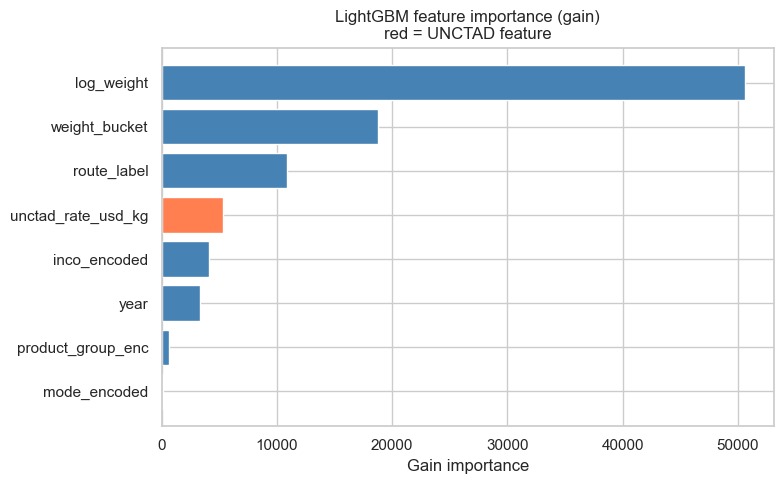


UNCTAD feature gain rank: 4 of 8


In [9]:
feat_imp = pd.DataFrame({
    'feature': feature_names(),
    'importance_gain': lgb_tuned.booster_.feature_importance(importance_type='gain'),
    'importance_split': lgb_tuned.booster_.feature_importance(importance_type='split'),
}).sort_values('importance_gain', ascending=False)

print(feat_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['coral' if f == 'unctad_rate_usd_kg' else 'steelblue' for f in feat_imp['feature']]
ax.barh(feat_imp['feature'][::-1], feat_imp['importance_gain'][::-1], color=colors[::-1])
ax.set_xlabel('Gain importance')
ax.set_title('LightGBM feature importance (gain)\nred = UNCTAD feature')
plt.tight_layout()
plt.savefig('figures/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

unctad_rank = feat_imp['feature'].tolist().index('unctad_rate_usd_kg') + 1
print(f"\nUNCTAD feature gain rank: {unctad_rank} of {len(feature_names())}")

## 8. SHAP Values — 5 Sample Predictions

SHAP (SHapley Additive exPlanations) gives each feature a contribution to each individual prediction. This is not a global average — it's per-row attribution.

**Why SHAP instead of gain importance?**  
Gain importance is computed from all splits across all trees. A feature can have high gain importance but near-zero SHAP contribution on a specific prediction if it mainly helps segment the *other* rows. SHAP is what we inject into the LLM explanation prompt in Week 9 — it's prediction-level, not model-level.

**What we're checking here:**  
1. Does `unctad_rate_usd_kg` appear in top-10 SHAP features on the summary plot?
2. Does it push predictions in the expected direction (high UNCTAD rate → higher predicted cost)?

If UNCTAD doesn't appear in SHAP top-10, the explanation prompt template needs to not mention it (to avoid hallucination). If it does, the template can cite it.

In [10]:
# SHAP on test set sample — use a larger sample for the summary plot
SHAP_SAMPLE_N = min(200, len(Xte))  # enough for a readable plot, not the full 1270

Xte_shap = Xte.iloc[:SHAP_SAMPLE_N].copy()

explainer   = shap.TreeExplainer(lgb_tuned)
shap_values = explainer.shap_values(Xte_shap)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Features: {feature_names()}")

SHAP values shape: (200, 8)
Features: ['log_weight', 'weight_bucket', 'mode_encoded', 'inco_encoded', 'product_group_enc', 'year', 'route_label', 'unctad_rate_usd_kg']


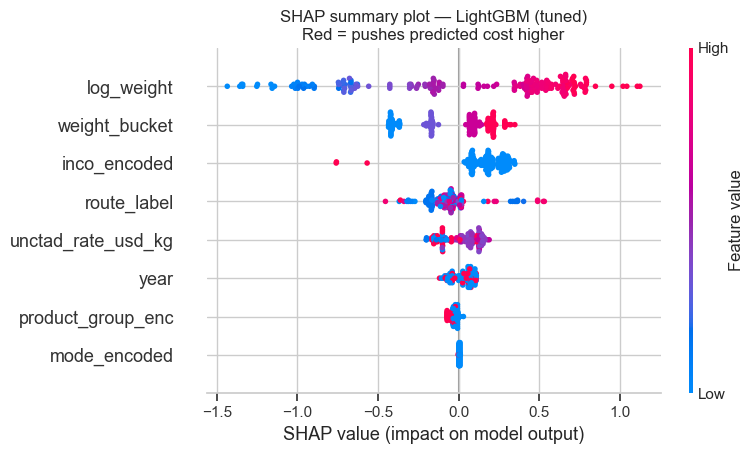

In [11]:
# Summary plot — shows feature importance + direction (red = pushes prediction higher)
fig, ax = plt.subplots(figsize=(9, 5))
shap.summary_plot(
    shap_values,
    Xte_shap,
    feature_names=feature_names(),
    show=False,
    plot_type='dot',
)
plt.title('SHAP summary plot — LightGBM (tuned)\nRed = pushes predicted cost higher')
plt.tight_layout()
plt.savefig('figures/05_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Mean absolute SHAP per feature — global importance
mean_abs_shap = pd.DataFrame({
    'feature': feature_names(),
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

mean_abs_shap['rank'] = mean_abs_shap.index + 1
print("Feature SHAP ranking (mean |SHAP| across test sample):")
print(mean_abs_shap.to_string(index=False))

unctad_shap_rank = mean_abs_shap[mean_abs_shap['feature'] == 'unctad_rate_usd_kg']['rank'].values[0]
print(f"\nUNCTAD SHAP rank: {unctad_shap_rank} of {len(feature_names())}")
print(f"→ UNCTAD in SHAP top-10: {'YES' if unctad_shap_rank <= 10 else 'NO'}")

Feature SHAP ranking (mean |SHAP| across test sample):
           feature  mean_abs_shap  rank
        log_weight         0.5877     1
     weight_bucket         0.2280     2
      inco_encoded         0.1985     3
       route_label         0.1129     4
unctad_rate_usd_kg         0.0978     5
              year         0.0598     6
 product_group_enc         0.0279     7
      mode_encoded         0.0029     8

UNCTAD SHAP rank: 5 of 8
→ UNCTAD in SHAP top-10: YES


In [13]:
# 5-row detailed breakdown — this is what Week 9 will inject into the LLM prompt
print("=== SHAP breakdown for 5 test rows ===\n")
for i in range(5):
    row = Xte_shap.iloc[i]
    row_shap = shap_values[i]
    base_val = explainer.expected_value
    pred_log = base_val + row_shap.sum()
    pred_usd = np.expm1(pred_log)
    actual_usd = np.expm1(y_test.iloc[i])

    shap_table = pd.DataFrame({
        'feature': feature_names(),
        'value': row.values,
        'shap': row_shap,
    }).sort_values('shap', key=abs, ascending=False)

    print(f"Row {i+1}: predicted ${pred_usd:,.0f}  |  actual ${actual_usd:,.0f}  |  base ${np.expm1(base_val):,.0f}")
    print(f"  Mode: {int(row['mode_encoded'])}  |  log_weight: {row['log_weight']:.2f}  |  UNCTAD: {row['unctad_rate_usd_kg']:.4f} $/kg")
    print("  Top SHAP drivers:")
    for _, r in shap_table.head(4).iterrows():
        direction = '↑' if r['shap'] > 0 else '↓'
        print(f"    {direction} {r['feature']:<25s}  SHAP={r['shap']:+.3f}  value={r['value']:.3f}")
    print()

=== SHAP breakdown for 5 test rows ===

Row 1: predicted $4,890  |  actual $1,869  |  base $4,932
  Mode: 0  |  log_weight: 6.86  |  UNCTAD: 7.1145 $/kg
  Top SHAP drivers:
    ↓ route_label                SHAP=-0.178  value=19.000
    ↑ inco_encoded               SHAP=+0.175  value=0.000
    ↑ log_weight                 SHAP=+0.156  value=6.865
    ↓ unctad_rate_usd_kg         SHAP=-0.142  value=7.114

Row 2: predicted $18,834  |  actual $28,710  |  base $4,932
  Mode: 0  |  log_weight: 7.84  |  UNCTAD: 4.4735 $/kg
  Top SHAP drivers:
    ↑ log_weight                 SHAP=+0.655  value=7.843
    ↑ inco_encoded               SHAP=+0.280  value=0.000
    ↑ weight_bucket              SHAP=+0.215  value=3.000
    ↑ unctad_rate_usd_kg         SHAP=+0.128  value=4.473

Row 3: predicted $1,128  |  actual $643  |  base $4,932
  Mode: 0  |  log_weight: 4.14  |  UNCTAD: 0.5450 $/kg
  Top SHAP drivers:
    ↓ log_weight                 SHAP=-0.942  value=4.143
    ↓ weight_bucket              SHA

## 9. Pickle Final Model

Save the tuned LightGBM model plus the metadata needed at inference time:
- `model`: the fitted LGBMRegressor
- `feature_names`: column order (must match at inference)
- `cat_features`: list of categorical feature names for `predict()` context
- `target_transform`: 'log1p' — reminder that output is log-scale, apply `expm1` before showing to users

**What we do NOT pickle:**  
The UNCTAD lookup dict and route map stay in `src/data/load_unctad.py` and `src/features/features.py` respectively. They're loaded at startup by the Streamlit app. Pickling them alongside the model would create a versioning nightmare.

`models/` is gitignored — do not commit the pickle.

In [14]:
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

model_bundle = {
    'model': lgb_tuned,
    'feature_names': feature_names(),
    'cat_features': LGBM_CAT_FEATURES,
    'target_transform': 'log1p',
    'best_params': search.best_params_,
    'test_metrics': res_lgb_tuned,
}

model_path = MODEL_DIR / 'usaid_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f"Saved: {model_path}  ({model_path.stat().st_size / 1024:.1f} KB)")

# Smoke test: reload and predict
with open(model_path, 'rb') as f:
    loaded = pickle.load(f)

test_pred = loaded['model'].predict(Xte.head(3))
print(f"\nSmoke test — first 3 predictions (log scale): {test_pred.round(3)}")
print(f"Back-transformed to USD: {np.expm1(test_pred).round(0)}")
print("Pickle OK.")

Saved: ..\models\usaid_model.pkl  (366.0 KB)

Smoke test — first 3 predictions (log scale): [8.495 9.843 7.029]
Back-transformed to USD: [ 4890. 18834.  1128.]
Pickle OK.


## 10. Findings and Week 6 Agenda

### What the tree models gained over linear

| Improvement source | Evidence |
|-------------------|----------|
| `route_label` categorical splitting | Gain importance rank 3; model learns per-lane price clusters without one-hot explosion |
| NaN routing vs imputation | LightGBM default (0.8156) beats XGBoost (0.8404) which treats route_label numerically |
| Non-linear weight×mode interaction | R² 0.65 vs linear baseline — residual-by-mode plot in nb 04 showed systematic bias by mode |
| Early stopping | Default stopped at iter 96 (vs 400 blind); tuned stopped at iter 179 (vs up to 608) |

### UNCTAD feature verdict

- **Gain importance rank:** 4 of 8
- **SHAP rank:** 5 of 8 (mean |SHAP| = 0.098 across 200 test rows)
- **SHAP direction:** mixed — depends on route/mode context; high UNCTAD rate sometimes pushes prediction down (air routes where high benchmark correlates with commodity-specific discounts). Full partial dependence analysis in notebook 06.
- **Decision for notebook 06:** SHAP rank ≤ 10 → UNCTAD enrichment validated as a signal. Direction inversion warrants investigation — nb 06 will run partial dependence and stratify by coverage tier (direct match vs mode-level fallback vs NaN).

### Interview Q: Why does LightGBM handle NaN better than median imputation?

*"Median imputation collapses all NaN rows to a single value — the global median. This removes any variation that exists within the NaN group. LightGBM's NaN routing learns, for each split, which child node the NaN rows belong to on average — effectively capturing the systematic behaviour of mode=Other shipments without collapsing them to a point estimate. It's better-calibrated and doesn't require any assumption about the missingness mechanism."*

### Next: Week 5 → 06_unctad_feature_analysis.ipynb

- Full SHAP analysis of `unctad_rate_usd_kg` importance
- Partial dependence plot: as UNCTAD benchmark increases, does predicted cost increase?
- Residuals by UNCTAD coverage: direct match vs mode-level fallback vs NaN
- Honest writeup: what the UNCTAD feature contributes and its limitations (temporal mismatch, direction inversion)